# Capítulo 2 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 2. Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

c1, c2 = 3.74e8, 1.44e4
sigma, S0 = 5.67e-8, 1361.0

## T1 — Wien a partir de Planck

**Solução.** Com $x = c_2/(\lambda T)$, a lei de Planck fica $E^*_\lambda \propto T^5 x^5/(e^x-1)$. Maximizar em $\lambda$ (a $T$ fixo) equivale a maximizar $x^5/(e^x-1)$ em $x$:
$$\frac{d}{dx}\frac{x^5}{e^x-1}=0 \;\Longrightarrow\; 5(e^x-1) = x e^x \;\Longrightarrow\; x = 5(1-e^{-x}),$$
cuja raiz não trivial é $x^* = 4{,}965$. Logo $\lambda_{max}T = c_2/x^* = 14400/4{,}965 = 2900\ \mu$m K ✓ (livro: 2897).

In [2]:
x = sp.symbols('x', positive=True)
xstar = sp.nsolve(x - 5*(1 - sp.exp(-x)), x, 5)
print(f'x* = {float(xstar):.6f}')
print(f'a = c2/x* = {c2/float(xstar):.1f} µm·K   (livro: 2897 µm·K) ✓')

x* = 4.965114
a = c2/x* = 2900.2 µm·K   (livro: 2897 µm·K) ✓


## T2 — Stefan–Boltzmann por integração de Planck

**Solução.** Com a mesma substituição $x = c_2/(\lambda T)$, $d\lambda = -c_2\,dx/(T x^2)$:
$$E^* = \int_0^\infty \frac{c_1\,d\lambda}{\lambda^5(e^{c_2/\lambda T}-1)}
 = \frac{c_1 T^4}{c_2^4}\int_0^\infty\frac{x^3}{e^x-1}dx
 = \frac{c_1 T^4}{c_2^4}\cdot\frac{\pi^4}{15},$$
ou seja $\sigma = \pi^4 c_1/(15\,c_2^4)$.

In [3]:
integral = sp.integrate(x**3/(sp.exp(x) - 1), (x, 0, sp.oo))
display(sp.Eq(sp.Integral(x**3/(sp.exp(x)-1), (x, 0, sp.oo)), integral))
sigma_teo = float(sp.pi**4/15) * c1 / c2**4
print(f'σ = π⁴c1/(15 c2⁴) = {sigma_teo:.3e} W m-2 K-4  (tabelado: 5,67e-8) ✓')

Eq(Integral(x**3/(exp(x) - 1), (x, 0, oo)), Integral(x**3/(exp(x) - 1), (x, 0, oo)))

σ = π⁴c1/(15 c2⁴) = 5.648e-08 W m-2 K-4  (tabelado: 5,67e-8) ✓


## T3 — Temperatura efetiva planetária

**Solução.** O planeta intercepta $\pi R^2(1-A)S$ (disco) e emite $4\pi R^2\sigma T_e^4$ (esfera inteira). Igualando: $T_e = [(1-A)S/(4\sigma)]^{1/4}$ — o fator 4 é a razão esfera/disco.

In [4]:
for nome, S, A, T_obs in [('Vênus', 2601.0, 0.77, 737),
                           ('Terra', 1361.0, 0.30, 288),
                           ('Marte', 586.0, 0.25, 210)]:
    Te = ((1-A)*S/(4*sigma))**0.25
    print(f'{nome:6s}: T_e = {Te:5.1f} K | superfície observada ~{T_obs} K | '
          f'estufa = {T_obs-Te:+6.1f} K')
print('\nVênus: albedo altíssimo derruba T_e a 227 K, mas o CO2 denso gera ~510 K de estufa!')

Vênus : T_e = 226.6 K | superfície observada ~737 K | estufa = +510.4 K
Terra : T_e = 254.6 K | superfície observada ~288 K | estufa =  +33.4 K
Marte : T_e = 209.8 K | superfície observada ~210 K | estufa =   +0.2 K

Vênus: albedo altíssimo derruba T_e a 227 K, mas o CO2 denso gera ~510 K de estufa!


## T4 — Estufa de uma camada

**Solução.** Camada transparente ao solar, opaca ao IV, a $T_a$; superfície a $T_s$.
- Balanço no topo: o que sai para o espaço é $\sigma T_a^4 = \sigma T_e^4$ ⇒ $T_a = T_e$.
- Balanço na superfície: recebe solar $\sigma T_e^4$ + IV da camada $\sigma T_a^4$, emite $\sigma T_s^4$:
$$\sigma T_s^4 = \sigma T_e^4 + \sigma T_a^4 = 2\sigma T_e^4 \;\Rightarrow\; T_s = 2^{1/4}T_e = 1{,}189\times255 = 303\ \mathrm{K}.$$
Observado: 288 K — o modelo superestima porque a atmosfera real não é totalmente opaca (janela atmosférica) e porque convecção (Cap. 3) exporta calor da superfície.

## T5 — Massa de ar e atenuação com o ângulo

**Solução.** Para atmosfera plano-paralela, o feixe com elevação $\Psi$ percorre $ds = dz/\sin\Psi$. A profundidade óptica ao longo do caminho é
$$\tau = \int k\rho\,\frac{dz}{\sin\Psi} = \frac{\tau_z}{\sin\Psi},\qquad \tau_z = \int_0^\infty k\rho\,dz,$$
logo $E = S_0\,e^{-\tau_z/\sin\Psi}$. A "massa de ar" $m = 1/\sin\Psi$ vale 1 com sol a pino, 2 a 30°, ~11 a 5° — por isso o pôr do sol é fraco (e vermelho: $\tau_z$ cresce para o azul, espalhamento Rayleigh $\propto\lambda^{-4}$).

---
## N1 — Wien e Stefan–Boltzmann numéricos

In [5]:
def planck(lam_um, T):
    with np.errstate(over='ignore'):          # exp estoura p/ λT pequeno → E ≈ 0, ok
        return c1/(lam_um**5*(np.exp(c2/(lam_um*T)) - 1))

lam = np.logspace(-2, 3, 20000)
for T in [5772.0, 288.0]:
    E = planck(lam, T)
    lmax_num = lam[np.argmax(E)]
    E_int = np.trapezoid(E, lam)
    print(f'T = {T:6.0f} K:  λmax num = {lmax_num:7.3f} µm | Wien: {2897/T:7.3f} µm || '
          f'∫E dλ = {E_int:.3e} | σT⁴ = {sigma*T**4:.3e}')

T =   5772 K:  λmax num =   0.502 µm | Wien:   0.502 µm || ∫E dλ = 6.270e+07 | σT⁴ = 6.293e+07
T =    288 K:  λmax num =  10.073 µm | Wien:  10.059 µm || ∫E dλ = 3.886e+02 | σT⁴ = 3.901e+02


## N2 — São Paulo × Oslo: dia mais curto

In [6]:
Phi_r, d_r, d_y = np.deg2rad(23.44), 173, 365.25
declinacao = lambda d: Phi_r*np.cos(2*np.pi*(d - d_r)/d_y)
H0 = lambda phi, dl: np.arccos(np.clip(-np.tan(phi)*np.tan(dl), -1, 1))

def insolacao_diaria(phi, d):
    dl = declinacao(d); h0 = H0(phi, dl)
    return S0/np.pi*(h0*np.sin(phi)*np.sin(dl) + np.cos(phi)*np.cos(dl)*np.sin(h0))

dias = np.arange(1, 366)
for nome, phi_g in [('São Paulo', -23.55), ('Oslo', 60.0)]:
    phi = np.deg2rad(phi_g)
    dur = 24/np.pi*H0(phi, declinacao(dias))
    i_min = np.argmin(dur)
    print(f'{nome:10s}: dia mais curto = dia {dias[i_min]:3d} '
          f'({dur[i_min]:5.2f} h), insolação nesse dia = '
          f'{insolacao_diaria(phi, dias[i_min]):5.0f} W/m²')
print('\nOslo tem dia de 5,9 h no solstício — e São Paulo nunca fica abaixo de ~10,6 h.')

São Paulo : dia mais curto = dia 173 (10.55 h), insolação nesse dia =   263 W/m²
Oslo      : dia mais curto = dia 356 ( 5.51 h), insolação nesse dia =    24 W/m²

Oslo tem dia de 5,9 h no solstício — e São Paulo nunca fica abaixo de ~10,6 h.


## N3 — Ajuste da profundidade óptica

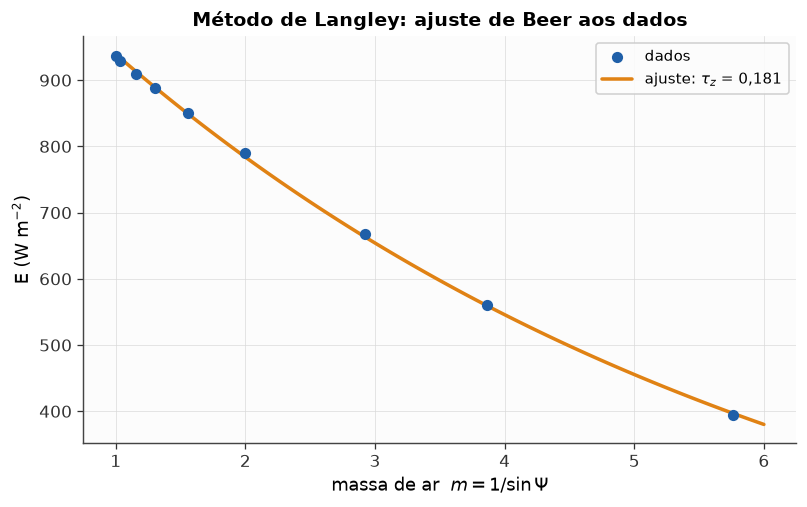

tau_z = 0.181;  S0 extrapolado = 1126 W/m²;  transmissividade a pino = 0.83


In [7]:
elev_dados = np.array([10, 15, 20, 30, 40, 50, 60, 75, 90])
E_dados    = np.array([395, 560, 668, 790, 851, 888, 910, 929, 936])

# linearização: ln E = ln S0 - tau_z * m, com m = 1/sin(elev)
m = 1/np.sin(np.deg2rad(elev_dados))
coef = np.polyfit(m, np.log(E_dados), 1)
tau_fit, lnS0_fit = -coef[0], coef[1]

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(m, E_dados, color=CORES['azul'], zorder=5, label='dados')
m_fino = np.linspace(1, 6, 100)
ax.plot(m_fino, np.exp(lnS0_fit)*np.exp(-tau_fit*m_fino), color=CORES['laranja'],
        label=f'ajuste: $\\tau_z$ = {tau_fit:.3f}'.replace('.', ','))
ax.set(xlabel='massa de ar  $m = 1/\\sin\\Psi$', ylabel='E (W m$^{-2}$)',
       title='Método de Langley: ajuste de Beer aos dados')
ax.legend()
plt.show()
print(f'tau_z = {tau_fit:.3f};  S0 extrapolado = {np.exp(lnS0_fit):.0f} W/m²;  '
      f'transmissividade a pino = {np.exp(-tau_fit):.2f}')

## N4 — Estufa de $N$ camadas

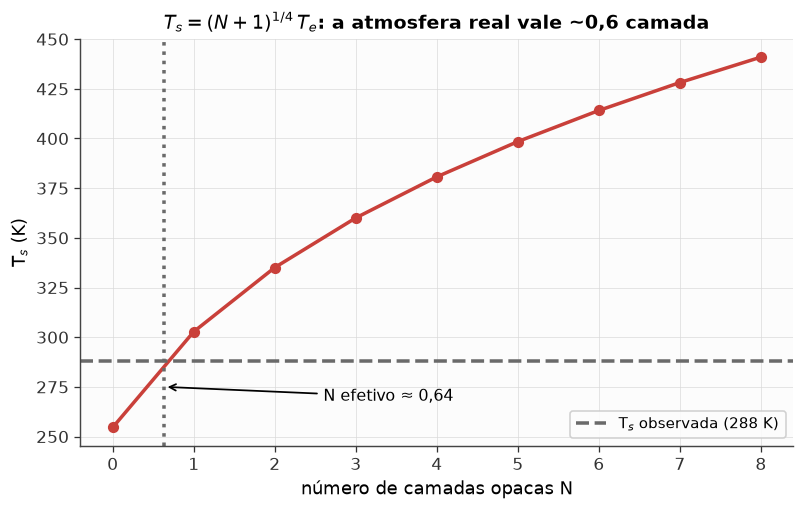

T_e = 254.6 K;  N efetivo = 0.64 — coerente com uma atmosfera
parcialmente transparente ao IV (janela atmosférica) + convecção.


In [8]:
A = 0.30
Te = ((1-A)*S0/(4*sigma))**0.25
N = np.arange(0, 9)
Ts = (N+1)**0.25 * Te

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(N, Ts, 'o-', color=CORES['vermelho'])
ax.axhline(288, color=CORES['cinza'], ls='--', label='T$_s$ observada (288 K)')
N_ef = (288/Te)**4 - 1
ax.axvline(N_ef, color=CORES['cinza'], ls=':')
ax.annotate(f'N efetivo ≈ {N_ef:.2f}'.replace('.', ','), xy=(N_ef, 275),
            xytext=(2.6, 268), fontsize=10,
            arrowprops=dict(arrowstyle='->', lw=1.1))
ax.set(xlabel='número de camadas opacas N', ylabel='T$_s$ (K)',
       title='$T_s = (N+1)^{1/4}\\,T_e$: a atmosfera real vale ~0,6 camada')
ax.legend()
plt.show()
print(f'T_e = {Te:.1f} K;  N efetivo = {N_ef:.2f} — coerente com uma atmosfera\n'
      'parcialmente transparente ao IV (janela atmosférica) + convecção.')

---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*